# 01_eda_overview

## Df preparing

In [120]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from IPython.display import display
from sympy import false

np.random.seed(42)
RAW_DIR = "../data/raw"

# Column names
AIR_STORE_ID_COL = "air_store_id"
HPG_STORE_ID_COL = "hpg_store_id"
VISIT_DATETIME_COL = "visit_datetime"
RESERVE_DATETIME_COL = "reserve_datetime"
VISIT_DATE_COL = "visit_date"
CALENDAR_DATE_COL = "calendar_date"
RESERVE_VISITORS_COL = "reserve_visitors"
VISITORS_COL = "visitors"

# Df names
AIR_VISIT_STR = "Air visit"
AIR_RESERVE_STR = "Air reserve"
HPG_RESERVE_STR = "Hpg reserve"
AIR_STORE_STR = "Air store"
HPG_STORE_STR = "Hpg store"

In [88]:
air_reserve_df = pd.read_csv(RAW_DIR + "/air_reserve.csv")
air_store_df = pd.read_csv(RAW_DIR + "/air_store_info.csv")
air_visit_df = pd.read_csv(RAW_DIR + "/air_visit_data.csv")

hpg_reserve_df = pd.read_csv(RAW_DIR + "/hpg_reserve.csv")
hpg_store_df = pd.read_csv(RAW_DIR + "/hpg_store_info.csv")

date_info_df = pd.read_csv(RAW_DIR + "/date_info.csv")
store_id_rel_df = pd.read_csv(RAW_DIR + "/store_id_relation.csv")
sample_submission_df = pd.read_csv(RAW_DIR + "/sample_submission.csv")

Next, need to designate the indexes and convert the dates to the required format.

In [89]:
def prepare_datetime_columns(df):
    df[VISIT_DATETIME_COL] = pd.to_datetime(df[VISIT_DATETIME_COL])
    df[RESERVE_DATETIME_COL] = pd.to_datetime(df[RESERVE_DATETIME_COL])
    df[VISIT_DATE_COL] = df[VISIT_DATETIME_COL].dt.normalize()

In [90]:
prepare_datetime_columns(air_reserve_df)
prepare_datetime_columns(hpg_reserve_df)

date_info_df[CALENDAR_DATE_COL] = pd.to_datetime(date_info_df[CALENDAR_DATE_COL])
air_visit_df[VISIT_DATE_COL] = pd.to_datetime(air_visit_df[VISIT_DATE_COL])

for df in [air_reserve_df, air_visit_df, hpg_reserve_df]:
    df.set_index(VISIT_DATE_COL, inplace=True)

sample_submission_df[[AIR_STORE_ID_COL, VISIT_DATE_COL]] = sample_submission_df["id"].str.rsplit("_", n=1, expand=True)
sample_submission_df[VISIT_DATE_COL] = pd.to_datetime(sample_submission_df[VISIT_DATE_COL])

Next, need to split the data by dates in air_reserve_df and hpg_reserve_df (not yet occurred and occurred).

In [91]:
min_sample_date = sample_submission_df[VISIT_DATE_COL].min()

air_res_occurred_df = air_reserve_df[air_reserve_df[VISIT_DATETIME_COL] < min_sample_date]
air_res_target_df = air_reserve_df[air_reserve_df[VISIT_DATETIME_COL] >= min_sample_date]

hpg_res_occurred_df = hpg_reserve_df[hpg_reserve_df[VISIT_DATETIME_COL] < min_sample_date]
hpg_res_target_df = hpg_reserve_df[hpg_reserve_df[VISIT_DATETIME_COL] >= min_sample_date]

Let"s determine the number of unique air_store_id"s that exist in the corresponding tables.

In [111]:
def get_unique_ids_and_print(df: pd.DataFrame, df_str: str, column: str):
    unique_ids = set(df[column].unique())
    print(f"{df_str} unique store ids: {len(unique_ids)}")
    return unique_ids

In [114]:
air_reserve_uniq_store_ids = get_unique_ids_and_print(air_reserve_df, AIR_RESERVE_STR, AIR_STORE_ID_COL)
air_visit_uniq_store_ids = get_unique_ids_and_print(air_visit_df, AIR_VISIT_STR, AIR_STORE_ID_COL)
air_store_uniq_store_ids = get_unique_ids_and_print(air_store_df, AIR_STORE_STR, AIR_STORE_ID_COL)

print(f"{AIR_RESERVE_STR} & {AIR_STORE_STR} ID matches: {len(air_store_uniq_store_ids & air_reserve_uniq_store_ids)}")
print(f"{AIR_VISIT_STR} & {AIR_STORE_STR} ID matches: {len(air_store_uniq_store_ids & air_visit_uniq_store_ids)}")

Air reserve unique store ids: 314
Air visit unique store ids: 829
Air store unique store ids: 829
Air reserve & Air store ID matches: 314
Air visit & Air store ID matches: 829


As you can see, the store_info table covers all the ids in the corresponding tables, but there are significantly fewer restaurants with reservation information than restaurants with daily visitor information.

In [117]:
hpg_reserve_uniq_store_ids = get_unique_ids_and_print(hpg_reserve_df, HPG_RESERVE_STR, HPG_STORE_ID_COL)
hpg_store_uniq_store_ids = get_unique_ids_and_print(hpg_store_df, HPG_STORE_STR, HPG_STORE_ID_COL)

print(f"{HPG_RESERVE_STR} & {HPG_STORE_STR} ID matches: {len(hpg_store_uniq_store_ids & hpg_reserve_uniq_store_ids)}")

Hpg reserve unique store ids: 13325
Hpg store unique store ids: 4690
Hpg reserve & Hpg store ID matches: 4690


There are significantly fewer hpg restaurants for which information is available than for which reservations are available.

In [7]:
print("Number of restaurants that have air/hpg compliance: ",
      min(len(set(store_id_rel_df[HPG_STORE_ID_COL].unique()) & hpg_reserve_uniq_store_ids),
          len(set(store_id_rel_df[AIR_STORE_ID_COL].unique()) & air_store_uniq_store_ids)))

Number of restaurants that have air/hpg compliance:  150


In [119]:
sample_subm_uniq_store_ids = get_unique_ids_and_print(sample_submission_df, "Sample submission", AIR_STORE_ID_COL)
print(f"Store & sample ID matches: {len(sample_subm_uniq_store_ids & air_store_uniq_store_ids)}")
print("Count of restaurants that have air/hpg compliance:",
      len(set(store_id_rel_df[AIR_STORE_ID_COL].unique()) & sample_subm_uniq_store_ids)
      )

Sample submission unique store ids: 821
Store & sample ID matches: 821
Count of restaurants that have air/hpg compliance: 150


## Descrbe/info

### Air reserve df

In [9]:
display(air_reserve_df.info())
display(air_reserve_df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 92378 entries, 2016-01-01 to 2017-05-31
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   air_store_id      92378 non-null  object        
 1   visit_datetime    92378 non-null  datetime64[ns]
 2   reserve_datetime  92378 non-null  datetime64[ns]
 3   reserve_visitors  92378 non-null  int64         
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 3.5+ MB


None

,visit_datetime,reserve_datetime,reserve_visitors
count,92378,92378,92378.000000
mean,2016-12-05 08:18:58.751651072,2016-11-27 01:13:07.707030016,4.481749
min,2016-01-01 19:00:00,2016-01-01 01:00:00,1.000000
25%,2016-11-15 19:00:00,2016-11-07 17:00:00,2.000000
50%,2017-01-05 18:00:00,2016-12-27 22:00:00,3.000000
75%,2017-03-03 19:00:00,2017-02-26 18:00:00,5.000000
max,2017-05-31 21:00:00,2017-04-22 23:00:00,100.000000
std,NaN,NaN,4.919669


air_reserve_df has no null values for visitors and dates.

In [10]:
print(f"Air reserve - occurred dates: {len(air_res_occurred_df)} observations")
print(f"Air reserve - not occurred dates: {len(air_res_target_df)} observations")

Air reserve - occurred dates: 90585 observations
Air reserve - not occurred dates: 1793 observations


Air reserve df consists of 92378 observations, of which 90585 are on the dataset with occurred dates, and 1793 are not.

### Air visit df

In [11]:
display(air_visit_df.info())
display(air_visit_df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252108 entries, 2016-01-13 to 2017-04-22
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   air_store_id  252108 non-null  object
 1   visitors      252108 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 5.8+ MB


None

,visitors
count,252108.000000
mean,20.973761
std,16.757007
min,1.000000
25%,9.000000
50%,17.000000
75%,29.000000
max,877.000000


air_visit_df has no null values and also has high variability for visitors.

### Air store df

In [12]:
display(air_store_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   air_store_id    829 non-null    object 
 1   air_genre_name  829 non-null    object 
 2   air_area_name   829 non-null    object 
 3   latitude        829 non-null    float64
 4   longitude       829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 32.5+ KB


None

### Date info df

In [13]:
display(date_info_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   calendar_date  517 non-null    datetime64[ns]
 1   day_of_week    517 non-null    object        
 2   holiday_flg    517 non-null    int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 12.2+ KB


None

### Hpg reserve df

In [14]:
display(hpg_reserve_df.info(show_counts=True))
display(hpg_reserve_df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2000320 entries, 2016-01-01 to 2017-05-31
Data columns (total 4 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   hpg_store_id      2000320 non-null  object        
 1   visit_datetime    2000320 non-null  datetime64[ns]
 2   reserve_datetime  2000320 non-null  datetime64[ns]
 3   reserve_visitors  2000320 non-null  int64         
dtypes: datetime64[ns](2), int64(1), object(1)
memory usage: 76.3+ MB


None

,visit_datetime,reserve_datetime,reserve_visitors
count,2000320,2000320,2.000320e+06
mean,2016-10-15 06:55:20.083586560,2016-10-07 19:57:59.307710464,5.073785e+00
min,2016-01-01 11:00:00,2016-01-01 00:00:00,1.000000e+00
25%,2016-06-26 19:00:00,2016-06-21 12:00:00,2.000000e+00
50%,2016-11-19 20:00:00,2016-11-10 20:00:00,3.000000e+00
75%,2017-02-03 19:00:00,2017-01-27 13:00:00,6.000000e+00
max,2017-05-31 23:00:00,2017-04-22 23:00:00,1.000000e+02
std,NaN,NaN,5.416172e+00


In [15]:
print(f"Hpg reserve - occurred dates: {len(hpg_res_occurred_df)} observations")
print(f"Hpg reserve - not occurred dates: {len(hpg_res_target_df)} observations")

Hpg reserve - occurred dates: 1964671 observations
Hpg reserve - not occurred dates: 35649 observations


Hpg reserve df consists of 2000320 observations, of which 1964671 are on the dataset with occurred dates, and 35649 are not.

### Hpg store df

In [16]:
display(hpg_store_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4690 entries, 0 to 4689
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hpg_store_id    4690 non-null   object 
 1   hpg_genre_name  4690 non-null   object 
 2   hpg_area_name   4690 non-null   object 
 3   latitude        4690 non-null   float64
 4   longitude       4690 non-null   float64
dtypes: float64(2), object(3)
memory usage: 183.3+ KB


None

There are no null values here either.

### Sample submission

In [17]:
display(sample_submission_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32019 entries, 0 to 32018
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            32019 non-null  object        
 1   visitors      32019 non-null  int64         
 2   air_store_id  32019 non-null  object        
 3   visit_date    32019 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 1000.7+ KB


None

## Missing values

### Start/end of restaurant accounting

In [71]:
import matplotlib.pyplot as plt

def plot_first_restaurant_mentions_hist(df: pd.DataFrame, df_str: str, grouping_col: str, date_col: str):
    df.reset_index().groupby(grouping_col)[date_col].min().hist(bins=50)
    plt.xlabel("Date of first mention")
    plt.ylabel("Count of restaurants")
    plt.title(f"{df_str} - First visit mention dates - Histogram")
    plt.show()

In [19]:
def plot_last_restaurant_mentions_hist(df: pd.DataFrame, df_str: str, grouping_col: str, date_col: str):
    df.reset_index().groupby(grouping_col)[date_col].max().hist(bins=50)
    plt.xlabel("Date of last mention")
    plt.ylabel("Count of restaurants")
    plt.title(f"{df_str} - Last visit mention dates - Histogram")
    plt.show()

#### Air visit df

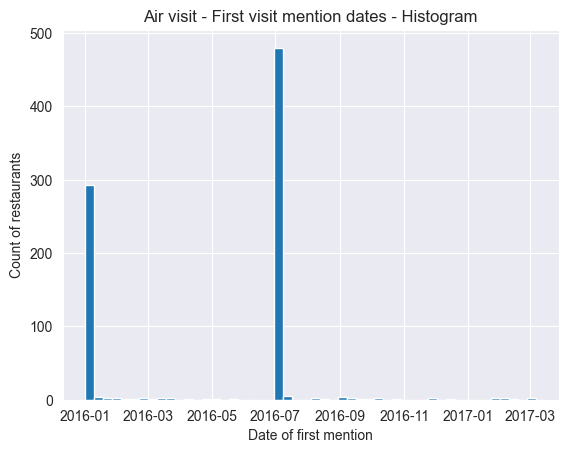

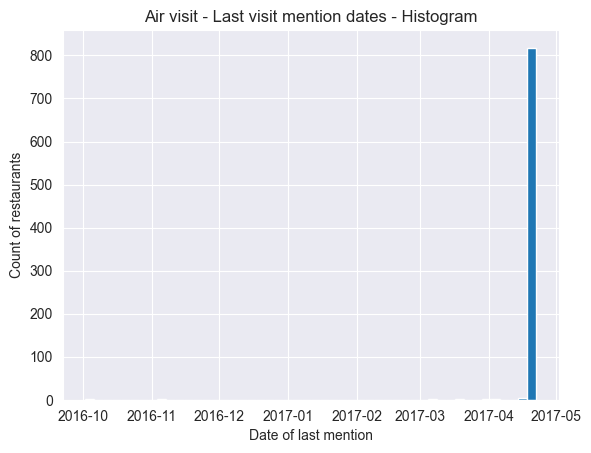

In [20]:
plot_first_restaurant_mentions_hist(air_visit_df, AIR_VISIT_STR, AIR_STORE_ID_COL, VISIT_DATE_COL)
plot_last_restaurant_mentions_hist(air_visit_df, AIR_VISIT_STR, AIR_STORE_ID_COL, VISIT_DATE_COL)

The graph shows that a large number of restaurants did not open immediately (in January 2016), but began somewhat later after the minimum visit date. The month with the highest frequency was July 2016.

Almost all restaurants are mentioned for the last time on the latest possible date. However, it's important to note that there are also a small number that closed much earlier.

#### Air reserve df

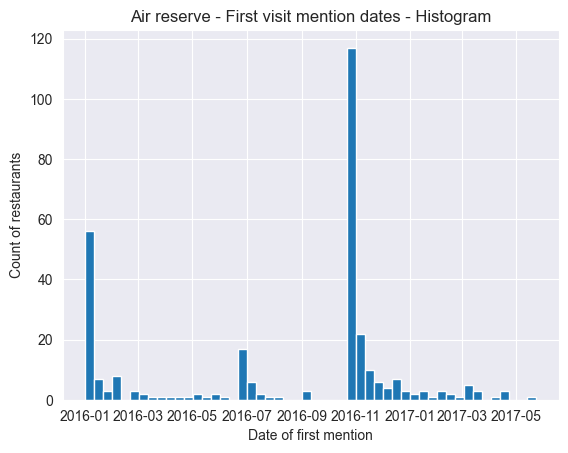

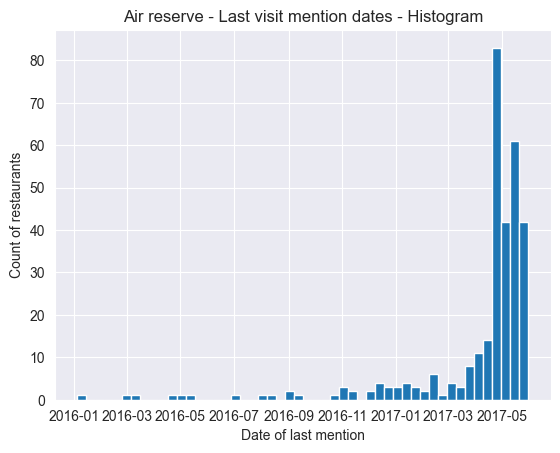

In [72]:
plot_first_restaurant_mentions_hist(air_reserve_df, AIR_RESERVE_STR, AIR_STORE_ID_COL, VISIT_DATE_COL)
plot_last_restaurant_mentions_hist(air_reserve_df, AIR_RESERVE_STR, AIR_STORE_ID_COL, VISIT_DATE_COL)

The graph shows that some restaurants are mentioned for the first time already in the predicted data. Most restaurants are last mentioned either on the earliest possible date that has already occurred, or during the dates for which data needs to be forecasted. However, there are quite a few restaurants that closed during the entire time period.

#### Hpg reserve df

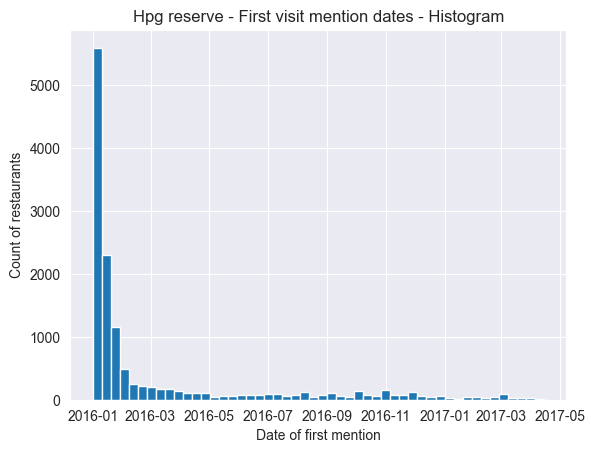

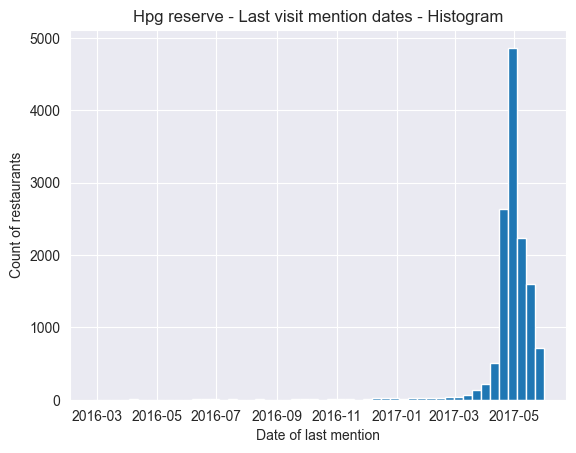

In [22]:
plot_first_restaurant_mentions_hist(hpg_reserve_df, HPG_RESERVE_STR, HPG_STORE_ID_COL, VISIT_DATE_COL)
plot_last_restaurant_mentions_hist(hpg_reserve_df, HPG_RESERVE_STR, HPG_STORE_ID_COL, VISIT_DATE_COL)

Most of the restaurants opened early (January 2016), but some still opened later. Here, as in the air reserve df, most restaurants are last mentioned on the last dates or on the dates for which forecast data is needed. There are also restaurants that closed during the entire time period, but their percentage is quite small compared to air reserve.

### Missing dates

It"s necessary to consider the percentage of missed dates for restaurants. However, some restaurants opened later than others, so two cases need to be considered: one with all dates missing, regardless of the opening date, and the other with this factor in.

In [23]:
def plot_opened_restaurants(df: pd.DataFrame, df_str: str, visit_col: str, store_col: str, count: bool = True):
    plt.figure(figsize=(10, 6))
    if count:
        df.groupby(visit_col)[store_col].count().plot()
    else:
        df.groupby(visit_col)[store_col].nunique().plot()
    plt.xlabel("Date")
    plt.ylabel("Count of opened (not missed) restaurants")
    plt.title(f"{df_str} - Not missed restaurants - Time plot")
    plt.show()

In [96]:
def get_opened_restaurants_pct(df: pd.DataFrame, visit_col: str, store_col: str, count: bool = True) -> pd.DataFrame:
    min_dates = df.reset_index().groupby(store_col)[visit_col].min()
    cumulative_restaurants = min_dates.sort_values().value_counts().sort_index().cumsum()

    if count:
        daily_restaurants = df.groupby(visit_col)[store_col].count()
    else:
        daily_restaurants = df.groupby(visit_col)[store_col].nunique()

    df_pct = pd.DataFrame({
        "daily_count": daily_restaurants,
        "total_existing": cumulative_restaurants.reindex(daily_restaurants.index, method="ffill")
    })
    df_pct["percentage"] = (df_pct["daily_count"] / df_pct["total_existing"] * 100)

    return df_pct

In [95]:
def plot_opened_restaurants_pct(df: pd.DataFrame, df_str: str):
    plt.figure(figsize=(10, 6))
    df["percentage"].plot()
    plt.xlabel("Date")
    plt.ylabel("Percentage of not missed restaurants (%)")
    plt.title(f"{df_str} - Percentage of not missed restaurants (including only mentioned restaurants) - Time plot")
    plt.grid(True)
    plt.show()

#### Air visit df

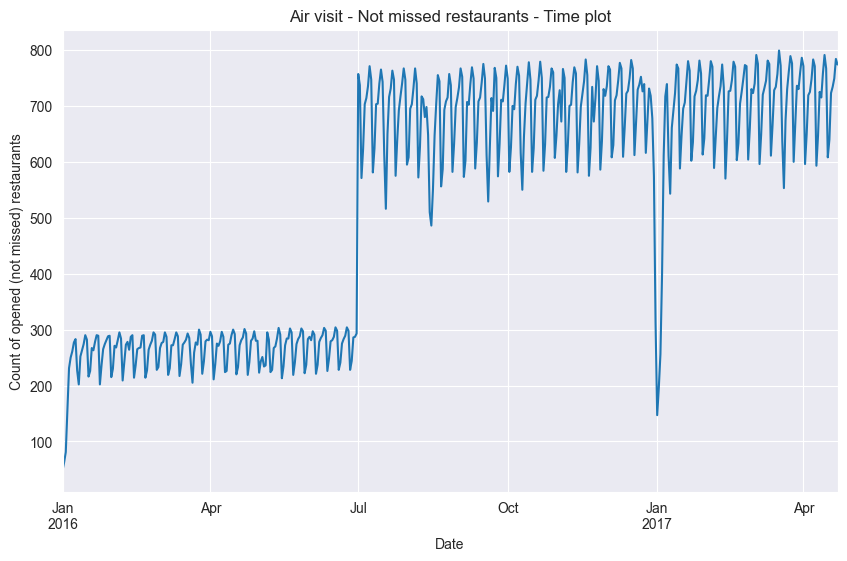

In [25]:
plot_opened_restaurants(air_visit_df, AIR_VISIT_STR, VISIT_DATE_COL, AIR_STORE_ID_COL)

There is a seasonal pattern in the missing dates. However, July 2016 saw a rise due to the opening (or first mention) of a large number of restaurants. Also in January 2017, a large number of restaurants were missed (there was a decline and rebound).

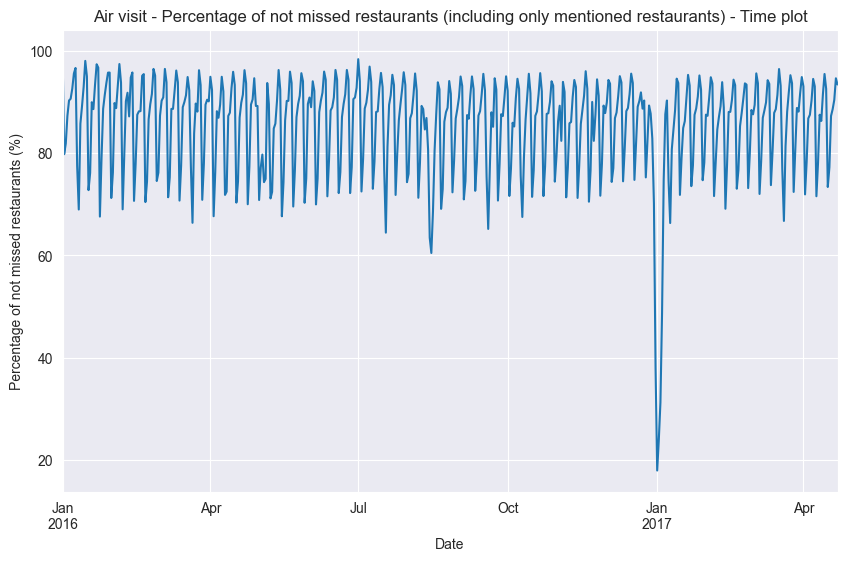

In [99]:
air_vis_msd_per_df = get_opened_restaurants_pct(air_visit_df, VISIT_DATE_COL, AIR_STORE_ID_COL)
plot_opened_restaurants_pct(air_vis_msd_per_df, AIR_VISIT_STR)

The graph shows seasonality in restaurant closures. However, unlike the previous graph, there is no rise in July (due to the number of restaurants not mentioned yet). A decline and rebound is also visible in January 2017.

#### Air reserve df

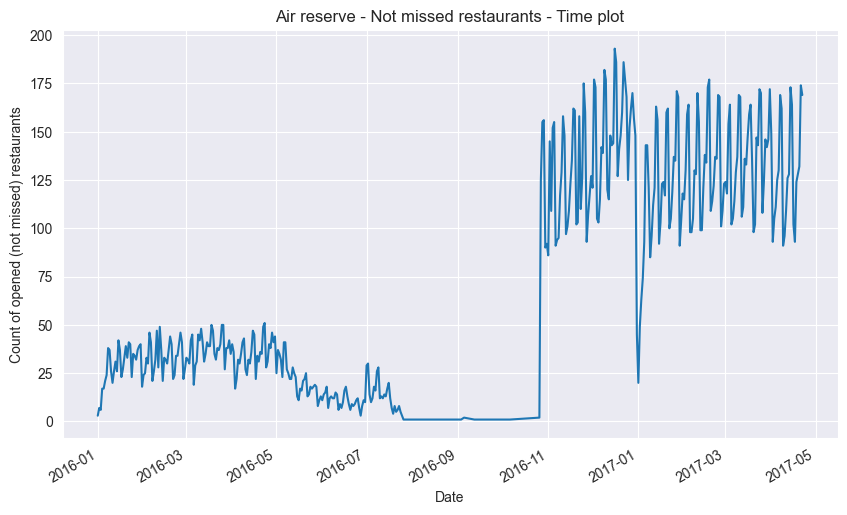

In [64]:
plot_opened_restaurants(air_res_occurred_df, AIR_RESERVE_STR, VISIT_DATE_COL, AIR_STORE_ID_COL, False)

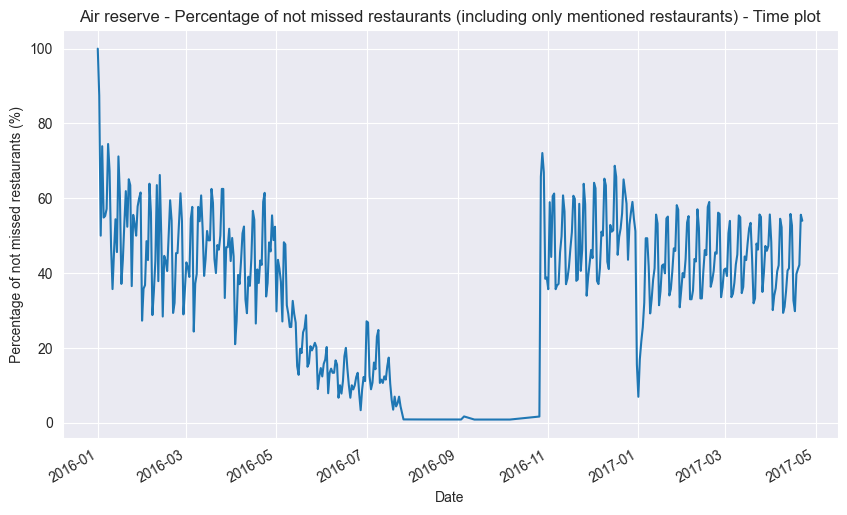

In [65]:
get_opened_restaurants_pct(air_res_occurred_df, AIR_RESERVE_STR, VISIT_DATE_COL, AIR_STORE_ID_COL, False)

Unlike air_visit df, the trend here is not as smooth. There is virtually no data for the period 2016-08 - 2016-10. Some seasonality is observed.

#### Hpg reserve df

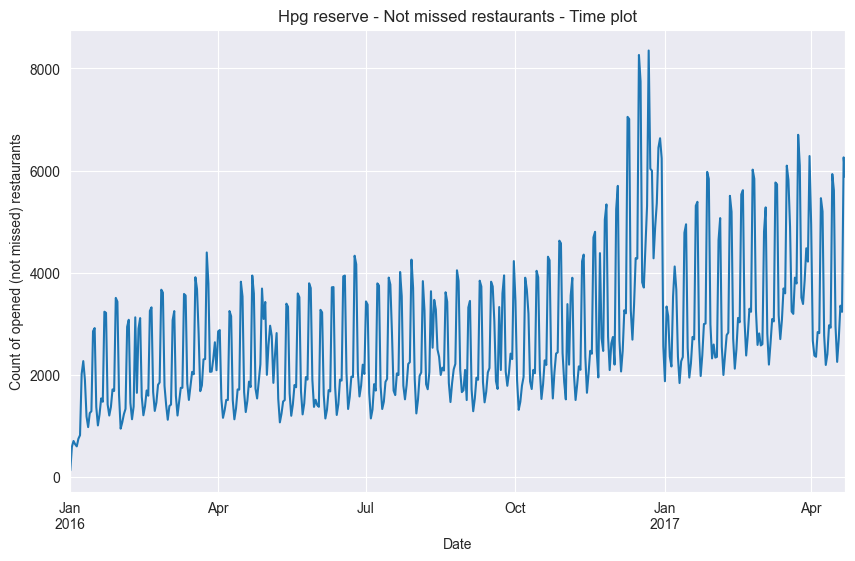

In [29]:
plot_opened_restaurants(hpg_res_occurred_df, HPG_RESERVE_STR, VISIT_DATE_COL, HPG_STORE_ID_COL, False)

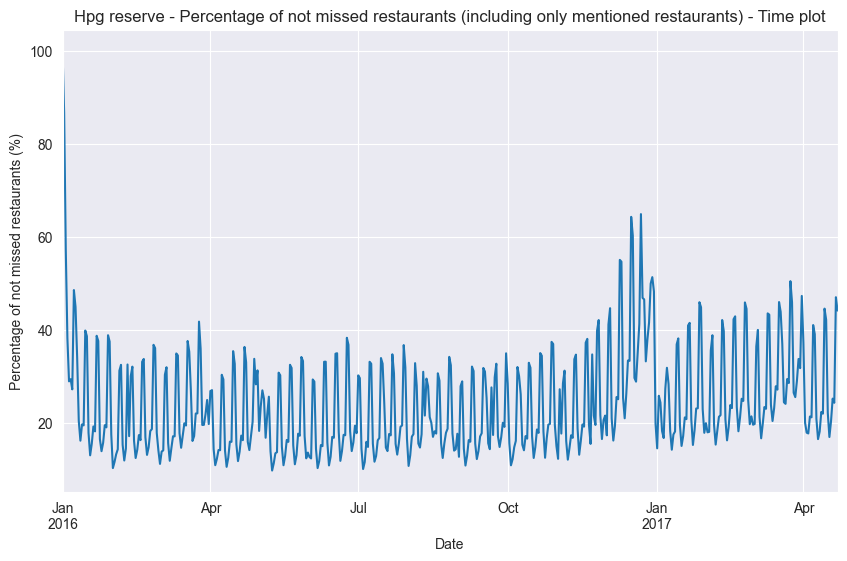

In [66]:
get_opened_restaurants_pct(hpg_res_occurred_df, HPG_RESERVE_STR, VISIT_DATE_COL, HPG_STORE_ID_COL, False)

The graph clearly shows seasonality. Seasonality can be observed both by day of the week and by week of the month. The trend increases towards January 2017 and then returns to its normal levels.

## Problematic data

### Number of visitors & number of reserved visitors

In [133]:
def find_reservations_exceed_visitors(grouping_df: pd.DataFrame, merging_df: pd.DataFrame, store_col: str, date_col: str, reserve_visitors_col, visitors_col) -> tuple[pd.DataFrame, pd.DataFrame]:
    daily_visitors = grouping_df.groupby([store_col, date_col])[reserve_visitors_col].sum().reset_index()
    merged_df = pd.merge(
        merging_df,
        daily_visitors,
        on=[store_col, date_col],
        how='inner',
    )

    problematic_rows = merged_df[
        merged_df[visitors_col] < merged_df[reserve_visitors_col]
    ][[date_col, store_col, visitors_col, reserve_visitors_col]]

    return problematic_rows, merged_df

def print_problematic_rows(problematic_rows: pd.DataFrame):
    print(f"Found {len(problematic_rows)} problematic rows")
    display(problematic_rows.head())

#### Air reserve & air visit

There may be cases when the number of planned visitors for a reservation (air reserve) exceeds the final number of visitors (air visit).

In [134]:
air_problematic_rows, air_visit_air_res = find_reservations_exceed_visitors(air_reserve_df, air_visit_df, AIR_STORE_ID_COL, VISIT_DATE_COL, RESERVE_VISITORS_COL, VISITORS_COL)
print_problematic_rows(air_problematic_rows)

Found 1146 problematic rows


,visit_date,air_store_id,visitors,reserve_visitors
0,2016-02-27,air_35512c42db0868da,6,12
139,2016-11-02,air_3e93f3c81008696d,8,31
140,2016-11-04,air_3e93f3c81008696d,5,11
143,2016-11-09,air_3e93f3c81008696d,2,4
147,2016-11-16,air_3e93f3c81008696d,13,14


#### Air visit & hpg reserve

In [32]:
air_visit_hpg_merged = pd.merge(
    air_visit_df.reset_index(),
    store_id_rel_df,
    on=[AIR_STORE_ID_COL],
    how='inner',
)

In [135]:
hpg_problematic_rows, air_visit_hpg_res = find_reservations_exceed_visitors(hpg_reserve_df, air_visit_hpg_merged, HPG_STORE_ID_COL, VISIT_DATE_COL, RESERVE_VISITORS_COL, VISITORS_COL)
print_problematic_rows(hpg_problematic_rows)

Found 548 problematic rows


,visit_date,hpg_store_id,visitors,reserve_visitors
28,2016-10-20,hpg_c2a8494d55fafbd6,6,9
35,2016-11-04,hpg_c2a8494d55fafbd6,5,7
51,2016-12-16,hpg_c2a8494d55fafbd6,18,20
69,2017-01-23,hpg_c2a8494d55fafbd6,2,14
71,2017-01-26,hpg_c2a8494d55fafbd6,3,6


#### Air visit & air reserve & hpg reserve

In [137]:
all_merged = pd.merge(
    air_visit_hpg_res,
    air_visit_air_res,
    on=[AIR_STORE_ID_COL, VISIT_DATE_COL, VISITORS_COL],
    how='inner',
)

overall_problematic_rows = all_merged[
    all_merged[VISITORS_COL] < all_merged['reserve_visitors_x'] + all_merged['reserve_visitors_y']
][[VISIT_DATE_COL, AIR_STORE_ID_COL, VISITORS_COL, 'reserve_visitors_x', 'reserve_visitors_y']]

print_problematic_rows(overall_problematic_rows)

Found 1644 problematic rows


,visit_date,air_store_id,visitors,reserve_visitors_x,reserve_visitors_y
2,2016-10-29,air_3e93f3c81008696d,42,28,17
3,2016-11-01,air_3e93f3c81008696d,76,3,74
4,2016-11-04,air_3e93f3c81008696d,5,7,11
8,2016-11-22,air_3e93f3c81008696d,7,4,13
13,2016-11-29,air_3e93f3c81008696d,17,7,12


### Reserve dates greater than visit dates

It is necessary to check the dataframes for date errors: are there any rows where the reservation datetime is greater than the visit datetime?

In [ ]:
def filter_by_column_comparison(df: pd.DataFrame, greater_column: str, smaller_column: str) -> pd.DataFrame:
    return df[df[greater_column] > df[smaller_column]]

#### Air reserve

In [ ]:
filter_by_column_comparison(air_reserve_df, RESERVE_DATETIME_COL, VISIT_DATETIME_COL)

There are no rows in the dataframe where the reservation datetime is greater than the visit datetime.

#### Hpg reserve

In [ ]:
filter_by_column_comparison(hpg_reserve_df, RESERVE_DATETIME_COL, VISIT_DATETIME_COL)

There are no rows in the dataframe where the reservation datetime is greater than the visit datetime.

## Time plots. Distribution. Box plots.

### Air reserve df

It is necessary to consider the distribution of the number of bookings per day (visited), the average number of visitors per day (visited). Visit data that has already occurred will be taken into account.

In [ ]:
plt.figure(figsize=(15, 10))

# Time plot
plt.subplot(2, 2, 1)
air_res_occurred_df.groupby(VISIT_DATE_COL)["reserve_visitors"].mean().plot(linewidth=0.8, color="orange")
plt.title("Air reserve - Mean visitors by visit date - Time Plot (1)")
plt.xlabel("Date")
plt.ylabel("Visitors count")
plt.grid(True, alpha=0.3)

# Visitors distribution
plt.subplot(2, 2, 2)
air_res_occurred_df.groupby(VISIT_DATE_COL)["reserve_visitors"].mean().hist(bins=50, edgecolor="black")
plt.title("Air reserve - Mean visitors by visit date - Histogram (2)")
plt.xlabel("Mean visitors count")
plt.ylabel("Count of days")
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(2, 2, 3)
air_res_occurred_df.groupby(VISIT_DATE_COL)["reserve_visitors"].mean().plot(kind="box", vert=False)
plt.title("Air reserve - Mean visitors by visit date - Box Plot (3)")
plt.xlabel("Mean visitors count")
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(2, 2, 4)
air_res_occurred_df.groupby(VISIT_DATE_COL)["reserve_visitors"].count().plot()
plt.title("Air reserve - Count of reservations by visit date - Time plot (4)")
plt.xlabel("Day")
plt.ylabel("Count of reservations")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

There was a certain period of time during which no bookings were made for the given dates, after which the number increased sharply. There are few outliers overall.

### Air visit df

It is necessary to consider the distribution of visitors for the date, the distribution of visitors for each restaurant, and outliers.

In [ ]:
plt.figure(figsize=(15, 10))

# Time plot
plt.subplot(2, 2, 1)
air_visit_df.groupby(VISIT_DATE_COL)["visitors"].mean().plot(linewidth=0.8, color="orange")
plt.title("Air visit - Mean visitors by date - Time plot (1)")
plt.xlabel("Date")
plt.ylabel("Mean visitors count")
plt.grid(True, alpha=0.3)

# Visitors distribution
plt.subplot(2, 2, 2)
air_visit_df.groupby(VISIT_DATE_COL)["visitors"].mean().hist(bins=50, edgecolor="black")
plt.title("Air visit - Mean visitors by date - Histogram (2)")
plt.xlabel("Mean visitors count")
plt.ylabel("Count of days")
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(2, 2, 3)
air_visit_df.groupby(VISIT_DATE_COL)["visitors"].mean().plot(kind="box", vert=False)
plt.title("Air visit - Mean visitors by date - Box Plot (3)")
plt.xlabel("Visitors count")
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(2, 2, 4)
air_visit_df.groupby(AIR_STORE_ID_COL)["visitors"].mean().hist(bins=30, edgecolor="black")
plt.title("Air visit - Mean visitors by restaurant - Histogram (4)")
plt.xlabel("Mean visitors count")
plt.ylabel("Count of restaurants")
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

There is some seasonality in the data. In the graph 2 the distribution is possibly multimodal. This may be due to the influence of holidays and non-holidays.

### Hpg reserve

It is necessary to consider the distribution of the number of bookings per day (visited), the average number of visitors per day (visited). Visit data that has already occurred will be taken into account.

In [ ]:
plt.figure(figsize=(15, 10))

# Time plot
plt.subplot(2, 2, 1)
hpg_res_occurred_df.groupby(VISIT_DATE_COL)["reserve_visitors"].mean().plot(linewidth=0.8, color="orange")
plt.title("Hpg reserve - Mean visitors by visit day - Time plot (1)")
plt.xlabel("Date")
plt.ylabel("Mean visitors count")
plt.grid(True, alpha=0.3)

# Visitors distribution
plt.subplot(2, 2, 2)
hpg_res_occurred_df.groupby(VISIT_DATE_COL)["reserve_visitors"].mean().hist(bins=50, edgecolor="black")
plt.title("Hpg reserve - Mean visitors by visit day - Histogram (2)")
plt.xlabel("Mean visitors count")
plt.ylabel("Count of dates")
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(2, 2, 3)
hpg_res_occurred_df.groupby(VISIT_DATE_COL)["reserve_visitors"].mean().plot(kind="box", vert=False)
plt.title("Hpg reserve - Mean visitors by visit day - Box Plot (3)")
plt.xlabel("Visitors count")
plt.grid(True, alpha=0.3)

# Box plot
plt.subplot(2, 2, 4)
hpg_res_occurred_df.groupby(VISIT_DATE_COL)["reserve_visitors"].count().plot()
plt.title("Hpg reserve - Reservations count by visit day - Box Plot (4)")
plt.xlabel("Date")
plt.ylabel("Reservations count")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In graph 1, in April 2016 and 2017, and December 2017, there were jumps in the average number of visitors per day. In January there is a sharp decline (for a couple of days), after which the values return to normal.
In graph 3. there are some outliers, mostly on the right side. In graph 4, there is seasonality for count of reservations per day, but December 2017 shows a significant jump. By January 2017, the values return to normal, but over time until April they gradually increase on average.

## Seasonal plots

In [ ]:
def add_seasonal_columns(df: pd.DataFrame):
    index: pd.DatetimeIndex = df.index

    df["year"] = index.year
    df["month"] = index.month
    df["week"] = index.isocalendar().week
    df["day"] = index.day_of_week
    df["day_str"] = index.strftime("%a")
    df["year_month"] = [str(x.year) + "_" + str(x.month) for x in df.index]

In [42]:
def plot_seasonal(df: pd.DataFrame, visitors_column_name: str, title: str):
    df_plot = (
        df[["month", "day_str", visitors_column_name, "day"]]
        .dropna()
        .groupby(["day_str", "month", "day"])
        .mean()[[visitors_column_name]]
        .reset_index()
    )
    df_plot = df_plot.sort_values(by="day", ascending=True)

    months = df_plot["month"].unique()
    colors = np.random.choice(list(mpl.colors.XKCD_COLORS.keys()), len(months), replace=False)

    plt.figure(figsize=(10, 6))
    for i, month in enumerate(months):
        if i > 0:
            month_data = df_plot[df_plot["month"] == month]
            plt.plot("day_str", visitors_column_name, data=month_data, color=colors[i], label=month)
            plt.text(len(month_data["day_str"]) - 1, month_data[visitors_column_name].iloc[-1], month, color=colors[i])

    plt.gca().set(ylabel= visitors_column_name, xlabel = "Week")
    plt.yticks(alpha=.7)
    plt.title(title)
    plt.show()

In [43]:
def plot_visitors_for_n_last_months(df, month: int, visitors_column_name: str):
    min_date = df.index.min()
    max_allowed_date = min_date + pd.DateOffset(months=month)
    df.loc[(df.index <= max_allowed_date)].groupby(VISIT_DATE_COL)[visitors_column_name].quantile(0.95).plot(
        title=f"Visitors for {month} month - Time Plot (95 quantile)", figsize=(10, 6), color="orange")

    plt.ylabel("Visitors")
    plt.xlabel("Date")
    plt.grid(alpha=0.3)
    plt.show()

### Hpg reserve df

It is necessary to research count of bookings depending on the day of the week and the month.

In [ ]:
plot_visitors_for_n_last_months(hpg_reserve_df, 3, "reserve_visitors")

There is no seasonality on the graph.

In [ ]:
add_seasonal_columns(hpg_reserve_df)

In [46]:
plot_seasonal(hpg_reserve_df, "reserve_visitors", "Hpg reserve - Weekly mean visitors")

The number of visitors for Saturdays and Sundays is constantly declining. There are months, where the average number of visitors on weekdays is significantly higher than on other months.

In [ ]:
add_seasonal_columns(hpg_res_msd_per_df)

In [48]:
plot_seasonal(hpg_res_msd_per_df, "percentage", "Hpg reserve - Weekly percentage of unmissed rows")

Weekly seasonality is observed here. However, December stands out from the others, with higher values.

### Air reserve df

It is necessary to research count of bookings depending on the day of the week and the month.

In [ ]:
plot_visitors_for_n_last_months(air_reserve_df, 3, "reserve_visitors")

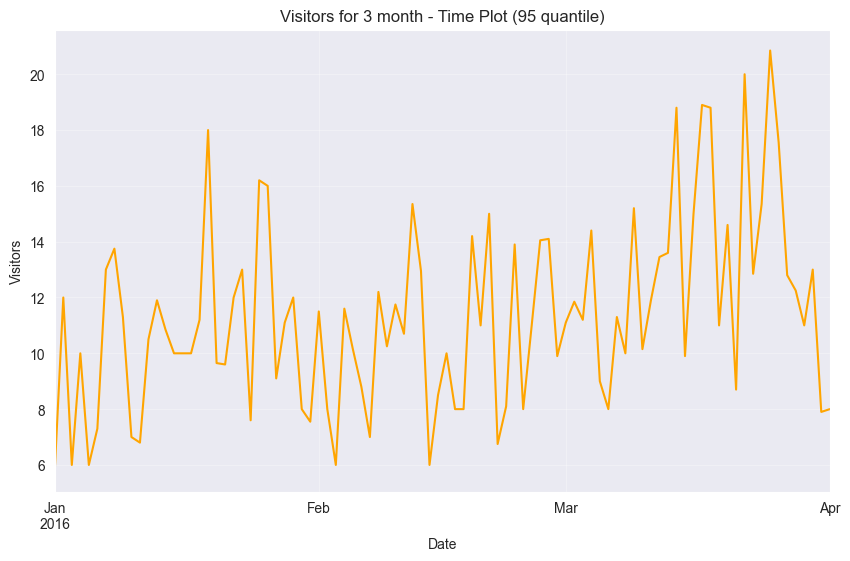

In [50]:
add_seasonal_columns(air_reserve_df)

In [51]:
plot_seasonal(air_reserve_df, "reserve_visitors", "Air reserve - Weekly mean visitors")

There is no specific seasonality. The eighth and ninth months are missing.

In [ ]:
add_seasonal_columns(air_res_msd_per_df)

In [53]:
plot_seasonal(air_res_msd_per_df, "percentage", "Air reserve - Weekly percentage of unmissed rows")

The highest percentage of restaurants are open (not missed) on Fridays and Saturdays. The overall percentage may drop in some months. Sunday has the lowest percentage of unmissed rows.

### Air visit data

In [ ]:
plot_visitors_for_n_last_months(air_visit_df, 3, "visitors")

We see a periodicity on the graph. It"s most likely related to the weekend.

In [ ]:
add_seasonal_columns(air_visit_df)

In [56]:
plot_seasonal(air_visit_df, "visitors", "Air visit - Weekly mean visitors")

The busiest hours are Friday through Sunday (and especially Saturday). There"s some slight fluctuation by month, but the trend remains consistent.

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="year_month", y="visitors", data=air_visit_df, showfliers=False)
plt.title("Distribution of Monthly Mean Visitors")
plt.xlabel("Year-Month")
plt.ylabel("Visitors")
plt.xticks(rotation=45)
plt.show()

The graph shows that the monthly average remains virtually unchanged, except for December, when demand increases.

In [ ]:
add_seasonal_columns(air_vis_msd_per_df)

In [59]:
plot_seasonal(air_vis_msd_per_df, "percentage", "Air visit - Weekly percentage of unmissed rows")

There is a clear seasonality in the missing data, likely related to the establishments' operating hours. Sundays have the highest percentage of missing data, while Fridays and Saturdays have the lowest.

## Conclusion

For restaurant reservation tables (air_reserve, hpg_reserve), the dates of visits that have already occurred and those that will occur are mixed, meaning that the number of visitors on these dates will need to be forecasted. Therefore, tables needed to be split into two parts. Some restaurants registered in air_store are not registered in hpg_store.

It is necessary to forecast the data for 821 restaurants, of which 150 have information in the hpg system.

#### Missing values

There are no null values in the data, but there are missing rows on certain dates for certain restaurants. In **hpg_store** and **air_store** only 150 ids match, while in air_store (and air_visit) there are only 829, and in hph_store there are 4690, also 13325 in hpg_reserve.

- In the **air_visit** df a large number of restaurants did not open immediately (in January 2016), but began somewhat later after the minimum visit date. Almost all restaurants are mentioned for the last time on the latest possible date. However, it's important to note that there are also a small number that closed much earlier. The month with the highest frequency was July 2016. There is seasonality in missing dates (maybe restaurant closures). A decline and rebound is visible in January 2017.
- In the **air_reserve** df some restaurants are mentioned for the first time already in the predicted data. Most restaurants are last mentioned either on the earliest possible date that has already occurred, or during the dates for which data needs to be forecasted. However, there are quite a few restaurants that closed during the entire time period. There are no rows in the dataframe where the reservation datetime is greater than the visit datetime. The trend for missing dates, unlike air_visit df, is not as smooth. There is virtually no data for the period 2016-08 - 2016-10. Some seasonality is observed.
- In the **hpg_reserve** df most of the restaurants first mentioned early (January 2016), but some still mentioned later. Here, as in the air reserve df, most restaurants are last mentioned on the last dates or on the dates for which forecast data is needed. There are also restaurants that closed during the entire time period, but their percentage is quite small compared to air reserve. There are no rows in the dataframe where the reservation datetime is greater than the visit datetime. For missing dates there is clearly shown seasonality. The trend increases towards January 2017 and then returns to its normal levels.

#### Problematic data

1146 records were found for merged air_visit and air_reserved where the number of visitors in the bookings exceeded the total number of visitors for the day for individual restaurants, 548 - for merged air_visit and hpg_reserved, of which 79 overlap with the previous table. For the intersection of air_visit, air_reserve, and hpg_reserve, 1644 such rows were found. However, it is impossible to claim that all of them are truly incorrect, as air_reserve and hpg_reserve may have overlapping bookings.


#### Time plots

- In the **air_visit** df there is some slight fluctuation by month, but the trend remains consistent. The distribution of the average number of visitors by day is possibly multimodal. This may be due to the influence of holidays and non-holidays.
- In the **air_reserve** df there was a certain period of time during which no bookings were made for the given dates, after which the number increased sharply. There are few outliers overall.
- In the **hpg_reserve** df, in April 2016 and 2017, and December 2017, there were jumps in the average number of visitors per day. In January there is a sharp decline (for a couple of days), after which the values return to normal, but over time until April they gradually increase on average.

#### Seasonality

- In the **air_visit** df there is a weekly seasonality in the data. Also, the busiest days are Friday through Sunday (and especially Saturday). There is a weekly seasonality in the missing data, likely related to the establishments' operating hours. Sundays have the highest percentage of missing data, while Fridays and Saturdays have the lowest.
- In the **air_reserve** df there is no specific seasonality. The eighth and ninth months are missing. For missing values the highest percentage of restaurants are open (not missed) on Fridays and Saturdays. The overall percentage may drop in some months. Sunday has the lowest percentage of unmissed rows.
- In the **hpg_reserve** the number of visitors for Saturdays and Sundays is constantly declining. There are months, where the average number of visitors on weekdays is significantly higher than on other months. For missing values weekly seasonality is observed. However, December stands out from the others, with higher values.

For restaurant reservation tables (air_reserve, hpg_reserve), the dates of visits that have already occurred and those that will occur are mixed, meaning that the number of visitors on these dates will need to be forecasted. Therefore, tables needed to be split into two parts. Some restaurants registered in air_store are not registered in hpg_store.

It is necessary to forecast the data for 821 restaurants, of which 150 have information in the hpg system.

#### Missing values

There are no null values in the data, but there are missing rows on certain dates for certain restaurants. In **hpg_store** and **air_store** only 150 ids match, while in air_store (and air_visit) there are only 829, and in hph_store there are 4690, also 13325 in hpg_reserve.

- In the **air_visit** df a large number of restaurants did not open immediately (in January 2016), but began somewhat later after the minimum visit date. Almost all restaurants are mentioned for the last time on the latest possible date. However, it's important to note that there are also a small number that closed much earlier. The month with the highest frequency was July 2016. There is seasonality in missing dates (maybe restaurant closures). A decline and rebound is visible in January 2017.
- In the **air_reserve** df some restaurants are mentioned for the first time already in the predicted data. Most restaurants are last mentioned either on the earliest possible date that has already occurred, or during the dates for which data needs to be forecasted. However, there are quite a few restaurants that closed during the entire time period. There are no rows in the dataframe where the reservation datetime is greater than the visit datetime. The trend for missing dates, unlike air_visit df, is not as smooth. There is virtually no data for the period 2016-08 - 2016-10. Some seasonality is observed.
- In the **hpg_reserve** df most of the restaurants first mentioned early (January 2016), but some still mentioned later. Here, as in the air reserve df, most restaurants are last mentioned on the last dates or on the dates for which forecast data is needed. There are also restaurants that closed during the entire time period, but their percentage is quite small compared to air reserve. There are no rows in the dataframe where the reservation datetime is greater than the visit datetime. For missing dates there is clearly shown seasonality. The trend increases towards January 2017 and then returns to its normal levels.

#### Problematic data

1146 records were found for merged air_visit and air_reserved where the number of visitors in the bookings exceeded the total number of visitors for the day for individual restaurants, 548 - for merged air_visit and hpg_reserved, of which 79 overlap with the previous table. For the intersection of air_visit, air_reserve, and hpg_reserve, 1644 such rows were found. However, it is impossible to claim that all of them are truly incorrect, as air_reserve and hpg_reserve may have overlapping bookings.


#### Time plots

- In the **air_visit** df there is some slight fluctuation by month, but the trend remains consistent. The distribution of the average number of visitors by day is possibly multimodal. This may be due to the influence of holidays and non-holidays.
- In the **air_reserve** df there was a certain period of time during which no bookings were made for the given dates, after which the number increased sharply. There are few outliers overall.
- In the **hpg_reserve** df, in April 2016 and 2017, and December 2017, there were jumps in the average number of visitors per day. In January there is a sharp decline (for a couple of days), after which the values return to normal, but over time until April they gradually increase on average.

#### Seasonality

- In the **air_visit** df there is a weekly seasonality in the data. Also, the busiest days are Friday through Sunday (and especially Saturday). There is a weekly seasonality in the missing data, likely related to the establishments' operating hours. Sundays have the highest percentage of missing data, while Fridays and Saturdays have the lowest.
- In the **air_reserve** df there is no specific seasonality. The eighth and ninth months are missing. For missing values the highest percentage of restaurants are open (not missed) on Fridays and Saturdays. The overall percentage may drop in some months. Sunday has the lowest percentage of unmissed rows.
- In the **hpg_reserve** the number of visitors for Saturdays and Sundays is constantly declining. There are months, where the average number of visitors on weekdays is significantly higher than on other months. For missing values weekly seasonality is observed. However, December stands out from the others, with higher values.